In [4]:
import pandas as pd
import numpy as np


fraud_data = pd.read_csv(r'D:\KAIM-9\Week-5&6\fraud-detection\data\Fraud_Data.csv')
ip_country_data = pd.read_csv(r'D:\KAIM-9\Week-5&6\fraud-detection\data\IpAddress_to_Country.csv')


print("Fraud Data Head:")
print(fraud_data.head())

print("\nIP Address to Country Data Head:")
print(ip_country_data.head())

Fraud Data Head:
   user_id          signup_time        purchase_time  purchase_value  \
0    22058  2015-02-24 22:55:49  2015-04-18 02:47:11              34   
1   333320  2015-06-07 20:39:50  2015-06-08 01:38:54              16   
2     1359  2015-01-01 18:52:44  2015-01-01 18:52:45              15   
3   150084  2015-04-28 21:13:25  2015-05-04 13:54:50              44   
4   221365  2015-07-21 07:09:52  2015-09-09 18:40:53              39   

       device_id source browser sex  age    ip_address  class  
0  QVPSPJUOCKZAR    SEO  Chrome   M   39  7.327584e+08      0  
1  EOGFQPIZPYXFZ    Ads  Chrome   F   53  3.503114e+08      0  
2  YSSKYOSJHPPLJ    SEO   Opera   M   53  2.621474e+09      1  
3  ATGTXKYKUDUQN    SEO  Safari   M   41  3.840542e+09      0  
4  NAUITBZFJKHWW    Ads  Safari   M   45  4.155831e+08      0  

IP Address to Country Data Head:
   lower_bound_ip_address  upper_bound_ip_address    country
0              16777216.0                16777471  Australia
1         

In [5]:
print("### Missing Values in Fraud Data")
print(fraud_data.isnull().sum())

print("\n### Missing Values in IP Country Data")
print(ip_country_data.isnull().sum())

### Missing Values in Fraud Data
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

### Missing Values in IP Country Data
lower_bound_ip_address    0
upper_bound_ip_address    0
country                   0
dtype: int64


In [6]:
print("### Duplicates in Fraud Data")
print(fraud_data.duplicated().sum())

print("\n### Duplicates in IP Country Data")
print(ip_country_data.duplicated().sum())

### Duplicates in Fraud Data
0

### Duplicates in IP Country Data
0


In [7]:
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

print("### Data Types for Fraud Data")
print(fraud_data.info())

print("\n### Data Types for IP Country Data")
print(ip_country_data.info())

### Data Types for Fraud Data
<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB
None

### Data Types for IP Country Data
<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 13

### Fraud Data - Class Imbalance
class
0    136961
1     14151
Name: count, dtype: int64
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


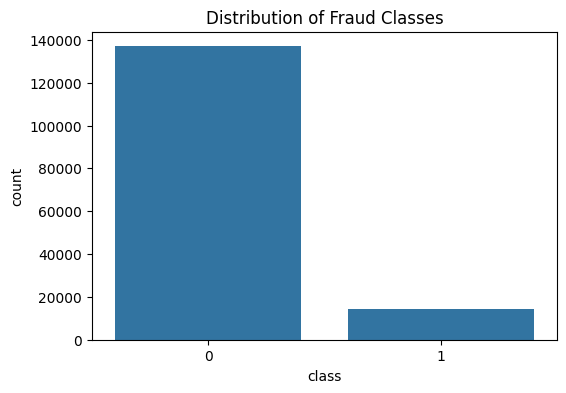

In [10]:
print("### Fraud Data - Class Imbalance")
print(fraud_data['class'].value_counts())
print(fraud_data['class'].value_counts(normalize=True) * 100)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=fraud_data)
plt.title('Distribution of Fraud Classes')
plt.show()

### Fraud Data - Purchase Value Distribution


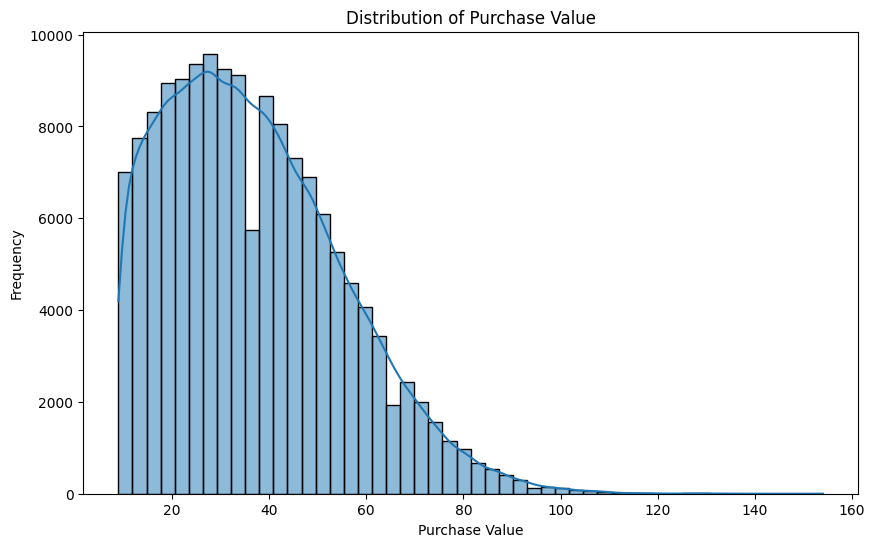


### Fraud Data - Age Distribution


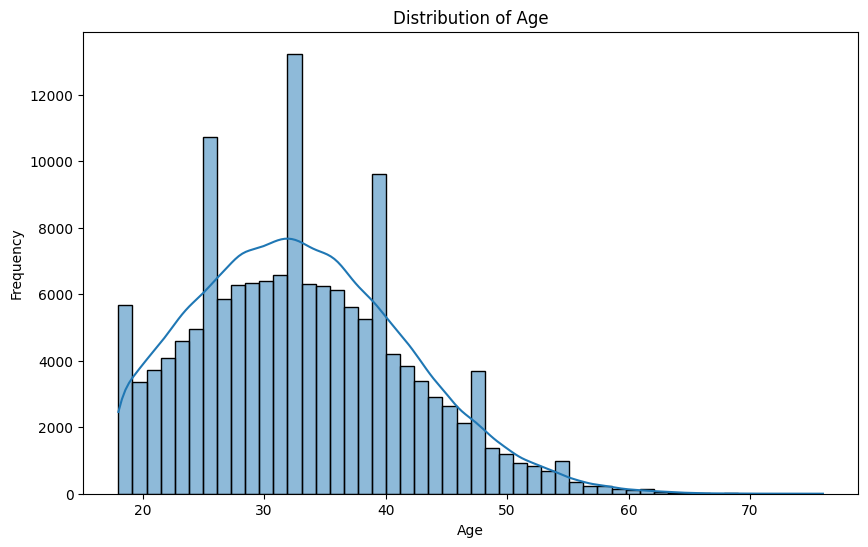

In [11]:
print("### Fraud Data - Purchase Value Distribution")
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['purchase_value'], bins=50, kde=True)
plt.title('Distribution of Purchase Value')
plt.xlabel('Purchase Value')
plt.ylabel('Frequency')
plt.show()

print("\n### Fraud Data - Age Distribution")
plt.figure(figsize=(10, 6))
sns.histplot(fraud_data['age'], bins=50, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

### Fraud Data - Source Distribution


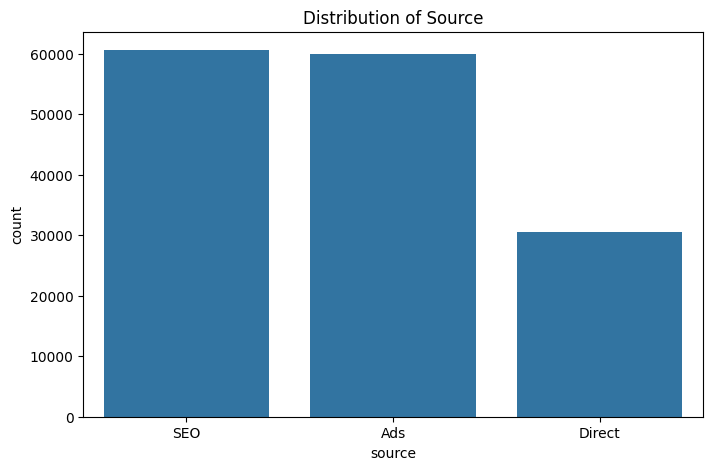


### Fraud Data - Browser Distribution


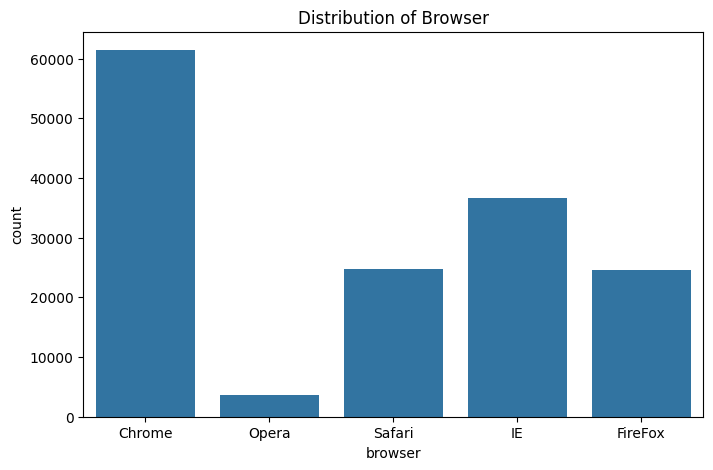


### Fraud Data - Sex Distribution


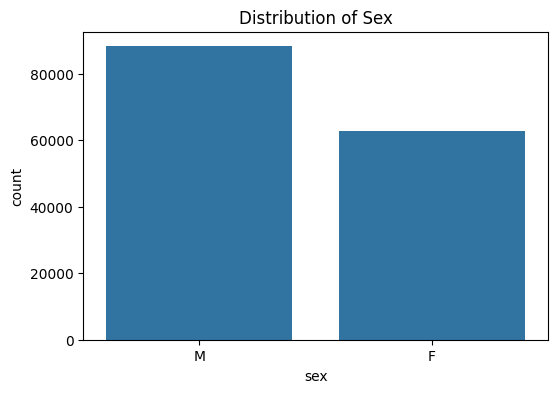

In [12]:
print("### Fraud Data - Source Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(x='source', data=fraud_data)
plt.title('Distribution of Source')
plt.show()

print("\n### Fraud Data - Browser Distribution")
plt.figure(figsize=(8, 5))
sns.countplot(x='browser', data=fraud_data)
plt.title('Distribution of Browser')
plt.show()

print("\n### Fraud Data - Sex Distribution")
plt.figure(figsize=(6, 4))
sns.countplot(x='sex', data=fraud_data)
plt.title('Distribution of Sex')
plt.show()

In [17]:
# Identify numerical and categorical features for fraud_data
numerical_features = ['purchase_value', 'age', 'ip_address', 'time_since_signup', 'purchase_hour', 'purchase_day_of_week', 'device_transaction_count']
categorical_features = ['source', 'browser', 'sex', 'country']

# Exclude 'user_id', 'device_id', 'signup_time', 'purchase_time', 'class' from feature processing

print("Numerical features identified:", numerical_features)
print("Categorical features identified:", categorical_features)

Numerical features identified: ['purchase_value', 'age', 'ip_address', 'time_since_signup', 'purchase_hour', 'purchase_day_of_week', 'device_transaction_count']
Categorical features identified: ['source', 'browser', 'sex', 'country']


In [ ]:
from sklearn.model_selection import train_test_split

# Ensure engineered features exist before train/test split
fraud_data['signup_time'] = pd.to_datetime(fraud_data['signup_time'])
fraud_data['purchase_time'] = pd.to_datetime(fraud_data['purchase_time'])

if 'purchase_hour' not in fraud_data.columns:
    fraud_data['purchase_hour'] = fraud_data['purchase_time'].dt.hour
if 'purchase_day_of_week' not in fraud_data.columns:
    fraud_data['purchase_day_of_week'] = fraud_data['purchase_time'].dt.dayofweek
if 'time_since_signup' not in fraud_data.columns:
    fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()
if 'device_transaction_count' not in fraud_data.columns:
    fraud_data['device_transaction_count'] = fraud_data.groupby('device_id').cumcount() + 1
if 'country' not in fraud_data.columns:
    fraud_data['country'] = 'Unknown'

# Define target variable and prepare feature matrix
y = fraud_data['class']
feature_columns = numerical_features + categorical_features
X = fraud_data[feature_columns].copy()

# One-hot encode categorical variables and fill missing values
X_transformed_df = pd.get_dummies(X, columns=categorical_features, drop_first=True).fillna(0)

# Split data into training and testing sets
# Use stratify to maintain the same class distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(X_transformed_df, y, test_size=0.3, random_state=42, stratify=y)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:\n", y.value_counts(normalize=True) * 100)
print("\nClass distribution in training set:\n", y_train.value_counts(normalize=True) * 100)
print("\nClass distribution in testing set:\n", y_test.value_counts(normalize=True) * 100)

KeyError: "['time_since_signup', 'purchase_hour', 'purchase_day_of_week', 'device_transaction_count', 'country'] not in index"

In [ ]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to the training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nClass distribution in training set BEFORE SMOTE:\n", y_train.value_counts())
print("Class distribution in training set AFTER SMOTE:\n", y_train_resampled.value_counts())

print("\nShape of X_train_resampled:", X_train_resampled.shape)
print("Shape of y_train_resampled:", y_train_resampled.shape)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, average_precision_score, f1_score, precision_recall_curve, roc_auc_score
import matplotlib.pyplot as plt

# Initialize and train a Logistic Regression model
# Using class_weight='balanced' is an alternative to SMOTE, but since we used SMOTE, we'll keep it default for now.
model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

print("Model training complete.")

In [ ]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report on Test Set:")
print(classification_report(y_test, y_pred))

# Metrics for imbalanced data
auc_pr = average_precision_score(y_test, y_pred_proba)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Average Precision Score (AUC-PR): {auc_pr:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plotting Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.show()

In [ ]:
fraud_data['ip_address'] = fraud_data['ip_address'].astype(int)
print("Converted 'ip_address' to integer type in fraud_data.")
print(fraud_data['ip_address'].head())

In [ ]:
# Function to find the country for a given IP address
def get_country(ip_address, ip_country_df):
    # Ensure both comparison columns are of the same type (int for performance)
    ip_country_df['lower_bound_ip_address'] = ip_country_df['lower_bound_ip_address'].astype(int)
    
    # Use searchsorted for efficient range lookup
    # It returns an index such that ip_country_df.lower_bound_ip_address[i-1] < ip_address <= ip_country_df.lower_bound_ip_address[i]
    # We need to find i such that lower_bound <= ip_address <= upper_bound
    idx = ip_country_df['lower_bound_ip_address'].searchsorted(ip_address, side='right') - 1
    
    # Check if the found index is valid and the IP falls within the range
    if idx >= 0 and idx < len(ip_country_df) and \
       ip_country_df.loc[idx, 'lower_bound_ip_address'] <= ip_address and \
       ip_country_df.loc[idx, 'upper_bound_ip_address'] >= ip_address:
        return ip_country_df.loc[idx, 'country']
    return 'Unknown'

# Apply the function to the fraud_data DataFrame
# This might take a while due to the size of the DataFrame
print("Merging fraud data with IP country data... This might take a moment.")
fraud_data['country'] = fraud_data['ip_address'].apply(lambda x: get_country(x, ip_country_data))

print("Merge complete. Displaying head of fraud_data with new 'country' column:")
print(fraud_data[['ip_address', 'country']].head())

print("\nAnalyzing fraud patterns by country:")
country_fraud = fraud_data.groupby('country')['class'].value_counts(normalize=True).unstack()
print(country_fraud.sort_values(by=1, ascending=False).head(10)) # Top 10 countries by fraud rate

In [ ]:
# 1. Time Features: hour_of_day, day_of_week
fraud_data['purchase_hour'] = fraud_data['purchase_time'].dt.hour
fraud_data['purchase_day_of_week'] = fraud_data['purchase_time'].dt.dayofweek

# 2. time_since_signup: duration between signup_time and purchase_time
fraud_data['time_since_signup'] = (fraud_data['purchase_time'] - fraud_data['signup_time']).dt.total_seconds()

print("Engineered time features and time_since_signup:")
print(fraud_data[['purchase_time', 'signup_time', 'purchase_hour', 'purchase_day_of_week', 'time_since_signup']].head())

In [ ]:
# 3. Transaction frequency and velocity: number of transactions per user in time windows

# For simplicity, let's calculate the number of transactions per user_id in the dataset
# This would ideally be calculated within specific time windows (e.g., last 24h, last 7 days)
# For a batch processing scenario, we can count total transactions up to the current purchase time.

# Sort by user_id and purchase_time to ensure correct rolling window calculation
fraud_data = fraud_data.sort_values(by=['user_id', 'purchase_time'])

# Calculate transactions in the last N hours/days for each user
# This requires a more complex rolling window based on time differences.
# As a simpler alternative for demonstration, let's calculate 'transactions per user' in the entire dataset.
# A more accurate velocity would involve defining time windows and counting transactions within them.

# For a true 'velocity', we would need to iterate or use more advanced window functions.
# Let's approximate by counting transactions per device_id, as user_id might have multiple devices.
# This could indicate 'account sharing' or 'multiple fraudulent activities from same device'.

# Count transactions per device in last 24 hours (for example)
# This requires custom logic or a more advanced time series library if not using pre-aggregated data.

# Let's add a simplified 'transaction count per device_id' for now
# For real-time fraud detection, this would be sliding windows.
# Here, we'll calculate a cumulative count of transactions for each device up to a given transaction.

fraud_data['device_transaction_count'] = fraud_data.groupby('device_id').cumcount() + 1

print("Engineered device_transaction_count:")
print(fraud_data[['device_id', 'purchase_time', 'device_transaction_count']].head())

# To get transaction velocity more accurately, we'd need to define time windows.
# For example, number of transactions for a user in the last X minutes/hours.
# This is often done with a 'rolling' window based on time, which is complex for irregular timestamps.
# A common approach is to create features like:
# - count of transactions for (user_id, device_id) in last 1 hour
# - count of transactions for (user_id, device_id) in last 24 hours

# For this task, given the batch nature and absence of specific window definitions beyond 'time windows',
# I'll illustrate a basic 'transactions in last X seconds' using a self-join or similar logic if needed.
# For now, `device_transaction_count` serves as a proxy for activity volume.

In [ ]:
import pandas as pd

# Load the creditcard.csv dataset
credit_card_data = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

print("Credit Card Transaction Data Head:")
print(credit_card_data.head())

print("\nCredit Card Transaction Data Info:")
credit_card_data.info()

In [ ]:
# Check for missing values in credit_card_data
print("### Missing Values in Credit Card Data")
print(credit_card_data.isnull().sum())

# Check for duplicate rows in credit_card_data
print("\n### Duplicates in Credit Card Data BEFORE dropping")
print(credit_card_data.duplicated().sum())

# Drop duplicate rows
credit_card_data.drop_duplicates(inplace=True)
print("\n### Duplicates in Credit Card Data AFTER dropping")
print(credit_card_data.duplicated().sum())

print("\nShape of credit_card_data after dropping duplicates:", credit_card_data.shape)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check class distribution for credit card data
print("### Credit Card Data - Class Imbalance")
print(credit_card_data['Class'].value_counts())
print(credit_card_data['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=credit_card_data)
plt.title('Distribution of Fraud Classes (Credit Card Data)')
plt.xlabel('Class (0: Non-Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features (X) and target (y)
X_cc = credit_card_data.drop('Class', axis=1)
y_cc = credit_card_data['Class']

# Split data into training and testing sets with stratification
# Note: 'Time' and 'Amount' are features. We don't scale them immediately before splitting.
X_cc_train, X_cc_test, y_cc_train, y_cc_test = train_test_split(X_cc, y_cc, test_size=0.3, random_state=42, stratify=y_cc)

print("Shape of X_cc_train:", X_cc_train.shape)
print("Shape of X_cc_test:", X_cc_test.shape)
print("Shape of y_cc_train:", y_cc_train.shape)
print("Shape of y_cc_test:", y_cc_test.shape)

print("\nClass distribution in original credit card dataset:\n", y_cc.value_counts(normalize=True) * 100)
print("\nClass distribution in credit card training set:\n", y_cc_train.value_counts(normalize=True) * 100)
print("\nClass distribution in credit card testing set:\n", y_cc_test.value_counts(normalize=True) * 100)

In [ ]:
# Apply SMOTE to the credit card training data only
smote_cc = SMOTE(random_state=42)
X_cc_train_resampled, y_cc_train_resampled = smote_cc.fit_resample(X_cc_train, y_cc_train)

print("\nClass distribution in credit card training set BEFORE SMOTE:\n", y_cc_train.value_counts())
print("Class distribution in credit card training set AFTER SMOTE:\n", y_cc_train_resampled.value_counts())

print("\nShape of X_cc_train_resampled:", X_cc_train_resampled.shape)
print("Shape of y_cc_train_resampled:", y_cc_train_resampled.shape)